<a href="https://colab.research.google.com/github/alexlimatds/esp_introducao_am/blob/main/04_caracterizacao_e_pre_processamento_de_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caracterização e Pré-processamento de Dados

No contexto do aprendizado de máquina, dados são definidos como representações simbólicas — numéricas, textuais, visuais ou sonoras — que descrevem fatos, medições, instâncias ou eventos do mundo real. A sua importância reside no fato de constituírem o próprio conhecimento bruto a partir do qual os algoritmos extraem padrões e tomam decisões. Exemplos práticos variam desde tabelas financeiras com o histórico de transações de um banco e arquivos de imagem para diagnóstico médico até sequências de comandos em áudio para assistentes virtuais e sinais captados por sensores industriais.

No entanto, os dados brutos raramente estão prontos para consumo direto por algoritmos. É nesse cenário que surge o **pré-processamento de dados**, definido como uma etapa essencial da computação preditiva destinada a limpar, transformar, organizar e adaptar os dados. Ele se faz estritamente necessário porque dados da vida real tendem a ser incompletos, ruidosos e inconsistentes. Ações como o preenchimento de campos vazios, a conversão de textos para formatos vetoriais e o reescalonamento numérico ilustram a aplicação do pré-processamento no dia a dia. (HAN, KAMBER e PEI, 2011)

Para planejar adequadamente esse tratamento prévio, utiliza-se a **caracterização de dados**. Este conceito refere-se à identificação das propriedades fundamentais das variáveis de um conjunto de dados. Caracterizar um conjunto de dados é importante para compreender quais premissas podem ser assumidas, permitindo escolher de forma fundamentada as transformações mais adequados para o conjunto de dados em questão.

## Caracterização de Dados

Ddoa podem ser categorizados de diversas formas dependendo da dimensão considerada. É importante entender essas categorizações para realizar as escolhas dos algoritmos de aprendizado de máquina mais apropriados (FACELI et al, 2025).
Sob o ponto de vista arquitetural e computacional, os conjuntos de dados podem ser categorizados sob quatro perspectivas principais:

* **Quanto à estrutura:** Os dados dividem-se em **estruturados**, que se organizam em tabelas com esquemas e colunas bem definidos (como bancos de dados SQL e planilhas CSV); **não estruturados**, que carecem de uma forma rígida predefinida e exigem abordagens avançadas para extração de características (como vídeos, áudios e arquivos PDF); e **semiestruturados**, que, embora não sigam o modelo tabular, contêm marcadores ou *tags* organizacionais internos (como documentos em formato JSON, XML ou HTML).
* **Quanto ao tempo ou frequência:** Classificam-se em **estáticos**, onde os registros permanecem inalterados ao longo do tempo (como um censo demográfico de um determinado ano); **dinâmicos**, atualizados periodicamente em lotes ou *batches* (como relatórios de fechamento diário de estoque); e **em tempo real (*streaming*)**, definidos por um fluxo contínuo e ininterrupto de informação processado à medida que chega ao sistema (como cotações do mercado financeiro e dados do sistema de telemetria de veículos autônomos).
* **Quanto à dependência:** Dizem-se **independentes** quando o valor de uma observação não exerce influência sobre o valor de outra, assumindo uma distribuição comumente tratada na literatura como *i.i.d.* (independentes e identicamente distribuídos), a exemplo das medidas de altura e peso de pessoas sorteadas ao acaso. Por outro lado, são **dependentes** quando há correlação temporal, espacial ou hierárquica entre os dados, como ocorre em séries temporais (previsão meteorológica) ou dados em rede e grafos (conexões entre usuários em redes sociais).
* **Quanto ao volume:** Trata-se da dimensão quantitativa do conjunto de dados. Quando a escala ultrapassa a capacidade de armazenamento e processamento de sistemas convencionais em memória RAM, o volume configura cenários de *Big Data*, exigindo técnicas de amostragem e ambientes distribuídos (como Apache Spark e Hadoop) para a leitura e modelagem das informações.

## Caracterização de Dados Estruturados

Os dados estruturados são comumente organizados no formato de matrizes ou tabelas, onde cada linha representa uma **instância** (ou exemplo) e cada coluna representa um **atributo** (ou variável de interesse). Dados estruturados são comumento utilizados em problemas de classificação e de regressão. Quando o atributo-alvo representa uma classe ou categoria, tem-se um problema de classificação. Nesse caso, o atributo-alvo armazena valores discretos. Por outro lado, um atributo-alvo que armazena valores numéricos contínuos careacteriza um problema de regressão.

Os valores que um atributo pode assumir podem ser caracterizados por **tipo** e por **escala**.

### Caracterização de atributos quanto ao tipo

Os atributos contidos em um dataset estruturado dividem-se primariamente em dois grandes grupos: qualitativo e quantitativo.

**Atributos qualitativos** descrevem qualidades, rótulos ou características não numéricas e também são chamados de atributos simbólicos ou categóricos. Esses atributos são discretos e geralmente pertencem a um conjunto finito. Exemplos de conjuntos de valores qualitativos são {solteiro, casado, divorciado}, {péssimo, ruim, mediano, bom, ótimo} e o conjunto das capitais brasileiras.

**Atributos quantitativos**, ou numéricos, representam medições ou contagens quantificáveis expressas por números. Podem assumir valores contínuos (e.g., valores reais como temperatura ou distância) ou discretos (e.g., valores inteiros como a quantidade de filhos).

É importante observar a prática de representar atributos qualitativos como números (por exemplo, atribuir a codificação `1` para masculino e `0` para feminino). Essa substituição é apenas uma convenção simbólica de representação computacional e não altera a natureza fundamental da variável: o dado continua sendo qualitativo, uma vez que operações aritméticas clássicas (como calcular a média desses valores) permanecem desprovidas de sentido direto (HAN, KAMBER e PEI, 2011).

### Caracterização de atributos quanto à escala

A escala define quais operações estatísticas e matemáticas são válidas para os valores de um atributo. As escalas nominal e ordinal aplicam-se a atributos qualitativos, enquanto que as escalas intervalar e racional aplicam-se a atributos quantitativos.

* **Escala Nominal:** Apenas categoriza e diferencia os elementos. Permite somente testes de igualdade ou diferença ($=$ ou $\neq$). *Exemplo:* código do país, tipo de documento de identificação.
* **Escala Ordinal:** Permite ordenar as categorias conforme uma hierarquia, embora a distância exata entre cada nível seja desconhecida. Habilita operações de comparação ($>$ ou $<$). *Exemplo:* classificação em um torneio esportivo (1º, 2º e 3º lugares), nível de satisfação (ruim, médio, bom).
* **Escala Intervalar:** Apresenta distâncias conhecidas e uniformes entre os pontos da escala, mas **não possui um zero absoluto**, sendo a origem da escala definida arbitrariamente. Admite operações de adição e subtração ($+$ ou $-$). *Exemplo:* temperatura medida em graus Celsius (onde 0 °C representa um ponto de congelamento arbitrário da água e não a ausência total de energia térmica). Em uma escala intervalar, o valor zero não tem o mesmo siginificado que o zero utilizado em operações aritméticas (FACELI et al, 2025).
* **Escala Racional (ou de Razão):** Possui distâncias conhecidas, uniformes e conta com a existência de um **zero absoluto**, que indica a ausência completa da propriedade medida. Permite a aplicação de qualquer operação aritmética, incluindo multiplicação e divisão ($\times$ ou $\div$). *Exemplo:* peso de um objeto, distância percorrida ou receita financeira (R$ 0,00 significa ausência total de dinheiro).

![diagrama de caracterização de atributos](https://github.com/alexlimatds/esp_introducao_am/blob/main/imagens/caracterizacao_atributos.png?raw=true)


### Exemplo: caracterização do Cleveland Heart Disease Dataset

O dataset **Cleveland Heart Disease** é uma base de dados clássica para tarefas de classificação na área de saúde. O dataset está disponível no [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease?utm_source=gemini) e foi coletado originalmente na Cleveland Clinic Foundation por Robert Detrano.

O objetivo principal do dataset é prever a presença ou ausência de doença cardíaca em um paciente com base em exames e atributos clínicos com a seguinte caracterização:

* **Volume e Estrutura:** Trata-se de um conjunto de dados **estruturado**, contendo **303 instâncias** (pacientes).
* **Atributos:** Embora o dataset original possua até 76 variáveis brutas, o dataset disponível no site UCI contém um subconjunto de **14 atributos** (13 atributos preditivos e 1 atributo alvo). O atributo alvo assume valores inteiros de 0 a 4, onde 0 significa ausência de doença cardíaca (grau de estreitamento do diâmetro da artéria < 50%) e os outros valores indicam o grau da doença cardíaca (estreitamento > 50%).

* **Qualidade dos Dados:** O conjunto possui uma quantidade pequena de dados ausentes (*missing values*), especificamente nos atributos `ca` e `thal`.

A tabela a seguir apresenta os 14 atributos do dataset Cleveland Heart Disease com suas descrições e classificações quanto ao tipo e à escala.

| Atributo | Descrição | Tipo | Escala |
| --- | --- | --- | --- |
| **age** | Idade do paciente em anos. | Quantitativo Discreto | Racional |
| **sex** | Sexo do paciente ($1$ = masculino; $0$ = feminino). | Qualitativo | Nominal |
| **cp** | Tipo de dor no peito ($1$ = angina típica; $2$ = angina atípica; <br>$3$ = dor não anginosa; $4$ = assintomático). | Qualitativo | Nominal |
| **trestbps** | Pressão arterial em repouso (em mmHg na admissão ao hospital). | Quantitativo discreto | Racional |
| **chol** | Colesterol sérico total em mg/dl. | Quantitativo discreto | Racional |
| **fbs** | Açúcar no sangue em jejum $> 120$ mg/dl <br>($1$ = verdadeiro; $0$ = falso). | Qualitativo | Nominal |
| **restecg** | Resultados eletrocardiográficos em repouso <br>($0$ = normal; $1$ = com alteração na onda ST-T; <br>$2$ = hipertrofia ventricular esquerda provável ou definitiva). | Qualitativo | Nominal |
| **thalach** | Frequência cardíaca máxima atingida em teste de esforço. | Quantitativo discreto | Racional |
| **exang** | Angina induzida por exercício ($1$ = sim; $0$ = não). | Qualitativo | Nominal |
| **oldpeak** | Depressão do segmento ST induzida pelo exercício em relação ao <br>repouso. | Quantitativo contínuo | Racional |
| **slope** | Inclinação do segmento ST no pico do exercício <br>($1$ = ascendente; $2$ = plano; $3$ = descendente). | Qualitativo | Ordinal |
| **ca** | Número de vasos principais ($0$ a $3$) coloridos por fluoroscopia. | Quantitativo discreto | Racional |
| **thal** | Teste de cintilografia com tálio <br>($3$ = normal; $6$ = defeito fixo; $7$ = defeito reversível). | Qualitativo | Nominal |
| **num** | Atributo alvo. Diagnóstico de doença cardíaca <br>($0$ = sem doença; $\{1, 2, 3, 4\} = $ com doença). | Qualitativo | Nominal |


In [1]:
# instalando biblioteca que permite carregar datasets diretamente do site UCI
!pip install ucimlrepo

In [2]:
# carregando dataset
from ucimlrepo import fetch_ucirepo
heart_disease = fetch_ucirepo(id=45)

# criando conjunto de features e conjunto com o atributo alvo (pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

In [3]:
# informações sobre os atributos
print('== ATRIBUTOS ==')
print(heart_disease.variables)

print('\nValores para o atributo sex:', X.sex.unique())
print('Valores para o atributo cp:', X.cp.unique())
print('Valores para o atributo fbs:', X.fbs.unique())
print('Valores para o atributo restecg:', X.restecg.unique())
print('Valores para o atributo exang:', X.exang.unique())
print('Valores para o atributo slope:', X.slope.unique())
print('Valores para o atributo thal:', X.thal.unique())

# contando o total de valores ausentes em cada coluna
print('\nQuantidade de valores ausentes por coluna:')
print(X.isna().sum())

# exibindo 10 instâncias aleatórias
display(X.sample(n=10))

== ATRIBUTOS ==
        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0                                                None  years             no  
1                                                None   None             no  

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
11,56,0,2,140,294,0,2,153,0,1.3,2,0.0,3.0
20,64,1,1,110,211,0,2,144,1,1.8,2,0.0,3.0
99,48,1,4,122,222,0,2,186,0,0.0,1,0.0,3.0
107,57,1,3,128,229,0,2,150,0,0.4,2,1.0,7.0
16,48,1,2,110,229,0,0,168,0,1.0,3,0.0,7.0
149,60,0,3,102,318,0,0,160,0,0.0,1,1.0,3.0
278,57,1,2,154,232,0,2,164,0,0.0,1,1.0,3.0
55,54,1,4,124,266,0,2,109,1,2.2,2,1.0,7.0
205,45,1,4,142,309,0,2,147,1,0.0,2,3.0,7.0
220,41,0,3,112,268,0,2,172,1,0.0,1,0.0,3.0


In [4]:
# Informações sobre o atributo alvo
print('== ATRIBUTO ALVO ==')

print('\nValores para o atributo alvo:', y.num.unique())
print('Quantidade de instâncias por cada valor do atributo:')
print(y.groupby('num').size())

== ATRIBUTO ALVO ==

Valores para o atributo alvo: [0 2 1 3 4]
Quantidade de instâncias por cada valor do atributo:
num
0    164
1     55
2     36
3     35
4     13
dtype: int64


## Pré-processamento

Além de diferentes características, conjuntos de dados podem apresentar imperfeições tais como ruídos, desbalanceamento, valores incosistentes, valores duplicados ou valores ausentes, as quais podem impactar o desempenho de modelos de aprendizado de máquina.
A etapa de pré-processamento tem como objetivo eliminar, ou mitigar, tais imperfeições, contibuindo com a melhoria dos resultados da aplicação.

### Eliminação Manual de Atributos

Refere-se à remoção deliberada de atributos com base na análise técnica de especialistas do domínio ou em inspeções estatísticas preliminares. A justificativa para essa ação apoia-se na eliminação de variáveis irrelevantes ou que possam gerar ruído sem adicionar poder preditivo, além de razões regulatórias ou éticas, como a remoção de informações sensíveis ou identitárias (por exemplo, o nome do usuário ou seu CPF). Outro cenário comum é a remoção de colunas com variância zero, nas quais todos os registros apresentam exatamente o mesmo valor constante.

### Amostragem

A amostragem consiste na extração de um subconjunto de instâncias extraído do universo total de dados disponível. Sua principal justificativa é viabilizar o desenvolvimento e o treinamento de modelos quando o volume total de dados exige um custo computacional inviável para a infraestrutura disponível ou quando o algoritmo possui dificuldade em lidar com um número grande de objetos.

A tomada de decisão por meio da amostragem estabelece um dilema entre **acurácia e custo computacional**: amostras muito pequenas reduzem exponencialmente o consumo de memória e o tempo de processamento, mas podem falhar ao não capturar fenômenos raros, degradando a precisão final do modelo. O ideal é que a amostra não seja grande, mas que seus dados obedeçam à mesms distribuição estatística do dataset original (FATELI et al, 2025). Entre os métodos mais aplicados destacam-se:

* **Amostragem Aleatória Simples sem Reposição:** Todos os elementos da população possuem idêntica probabilidade de serem selecionados e uma instância selecionada não pode ser selecionada novamente.
* **Amostragem Aleatória Simples com Reposição:** Similar à anterior, porém a instância sorteada é devolvida ao conjunto total, podendo ser selecionada novamente no mesmo subconjunto.
* **Amostragem Estratificada:** A população é dividida em estratos ou grupos mutuamente exclusivos com base em um atributo crítico (como a classe de saída), e a amostragem é realizada proporcionalmente dentro de cada estrato, garantindo a preservação das proporções originais da população no conjunto final.
* **Amostragem Progressiva:** Inicia-se o treinamento do modelo com uma amostra reduzida, incrementando progressivamente o seu tamanho até que o desempenho computacional do algoritmo atinja um patamar de estabilização do aprendizado.

### Conjuntos Desbalanceados

O problema de dados desbalanceados ocorre quando as instâncias pertencentes às categorias do atributo alvo estão distribuídas de maneira extremamente desproporcional no dataset.

A categoria com maior volume de instâncias é denominada **classe majoritária**, enquanto a categoria com poucos exemplos é chamada de **classe minoritária**. Esse cenário é frequente em problemas como a detecção de fraudes financeiras (onde a esmagadora maioria das transações é legítima) e o diagnóstico de doenças raras.

Classificadores treinados em datasets desbalanceados sem o devido tratamento tendem a apresentar alto viés favorável à classe majoritária. Nesses casos, o modelo pode prever sistematicamente a classe dominante e atingir um valor elevado de acurácia global, mas falhar em identificar os casos raros que constituem o real objetivo do sistema preditivo. Para contornar esse problema, utilizam-se técnicas específicas de balanceamento:

* **Sobreamostragem (*Oversampling*):** Incrementa a quantidade de exemplos da classe minoritária através da duplicação de instâncias existentes ou da criação sintética de novos dados (como na técnica SMOTE).
* **Subamostragem (*Undersampling*):** Reduz aleatoriamente a quantidade de observações da classe majoritária para equipará-la à minoritária, assumindo o risco de eliminar informações potencialmente relevantes do conjunto de dados.
* **Ajuste da Função de Custo do Classificador:** Modifica a indução do modelo aumentando a penalização matemática para erros cometidos na predição de exemplos pertencentes à classe minoritária durante a fase de treinamento (*Cost-sensitive Learning*).

### Limpeza de Dados

A limpeza de dados concentra-se em tratar inconsistências físicas e lógicas contidas no dataset bruto. A justificativa para este procedimento apoia-se no fato de que os dados reais frequentemente contêm **ruídos** (erros aleatórios de medição ou digitação), **inconsistências** (informações que se contradizem do ponto de vista lógico), **redundâncias** (registros ou atributos duplicados desnecessariamente) e **ausências** (valores faltantes ou não preenchidos).

As técnicas de limpeza abrangem o tratamento de valores faltantes por meio da exclusão de linhas com muitos campos vazios ou da imputação de valores com base em métricas como média, mediana ou moda das variáveis. Para a atenuação de ruídos, empregam-se métodos de suavização como o agrupamento por compartimentos (*binning*) e regressões, além da remoção sistemática de registros duplicados via identificação de chaves primárias ou correspondências exatas.

### Transformação de Dados

A transformação de dados reorganiza os atributos para ajustá-los às premissas matemáticas dos algoritmos de aprendizado de máquina. Por exemplo, redes neurais e máquinas de vetor de suporte lidam apenas com dados numéricos, o que exige a conversão de atributos qualitativos para um formato quantitativo.









#### Conversão simbólico-numérico

A **conversão simbólico-numérico** (ou codificação categórica) traduz atributos qualitativos em formatos numéricos compatíveis com operações matemáticas. Ela utiliza estratégias como o One-Hot Encoding (que cria novas colunas binárias para cada categoria presente) ou o Ordinal Encoding (que atribui inteiros sequenciais respeitando a ordem das variáveis ordinais).

Atributos categóricos nominais representam categorias que não possuem qualquer relação de ordem, hierarquia ou prioridade entre si.
Se atribuirmos inteiros sequenciais simples a essas categorias (por exemplo: *Carro* = 1, *Moto* = 2, *Caminhão* = 3), o algoritmo interpretará erroneamente que *Caminhão* é três vezes "maior" que *Carro*, ou que a distância entre *Carro* e *Moto* é menor que entre *Carro* e *Caminhão*. Para evitar a criação dessa hierarquia inexistente, utiliza-se a técnica de **One-Hot Encoding** (ou Codificação Unívoca), a qual converte cada atributo categórico em múltiplas colunas binárias, onde cada coluna corresponde a uma das categorias possíveis do atributo original. Para cada linha do dataset, a coluna correspondente à categoria presente recebe o valor $1$ (*hot*), enquanto todas as demais colunas criadas recebem o valor $0$ (*cold*).

Por exemplo, considere uma coluna original chamada `Cor_Veiculo` em um dataset de vendas de automóveis:

| ID_Veiculo | Cor_Veiculo |
| --- | --- |
| 1 | Vermelho |
| 2 | Azul |
| 3 | Verde |
| 4 | Vermelho |

Após a aplicação do One-Hot Encoding, o atributo `Cor_Veiculo` é desmembrado em três novas colunas binárias:

| ID_Veiculo | Cor_Vermelho | Cor_Azul | Cor_Verde |
| --- | --- | --- | --- |
| 1 | **1** | 0 | 0 |
| 2 | 0 | **1** | 0 |
| 3 | 0 | 0 | **1** |
| 4 | **1** | 0 | 0 |


O **Ordinal Encoding** atribui inteiros sequenciais (geralmente iniciando em $0$ ou $1$) às categorias de forma a preservar a relação de ordem existente entre elas. Ao contrário do One-Hot Encoding, esta técnica não cria novas colunas, mantendo a dimensionalidade original do dataset.

Por exemplo, considere uma coluna original chamada `Escolaridade` em um dataset de candidatos a uma vaga de trabalho:

| ID_Candidato | Escolaridade (Original) |
| --- | --- |
| 1 | Médio |
| 2 | Pós-Graduação |
| 3 | Fundamental |
| 4 | Superior |

Podemos mapear os valores da seguinte forma: `Fundamental` $\to 0$, `Médio` $\to 1$, `Superior` $\to 2$, `Pós-Graduação` $\to 3$:

| ID_Candidato | Escolaridade (Ordinal Encoded) |
| --- | --- |
| 1 | **1** |
| 2 | **3** |
| 3 | **0** |
| 4 | **2** |

Ao converter `Pós-Graduação` para $3$ e `Fundamental` para $0$, o algoritmo compreende corretamente que a escolaridade do candidato $2$ está em um patamar superior à do candidato $3$, preservando a estrutura inerente aos dados.

Quando um atributo categórico possui dezenas, centenas ou milhares de valores possíveis, como o município de residência de uma pessoa (com mais de 5.500 categorias no Brasil), o One-Hot Encoding gera uma coluna binária para cada categoria existente. Esse crescimento explosivo no número de colunas adicionais acarreta problemas significativos:

- Maldição da Dimensionalidade: O espaço de busca do modelo expande-se dramaticamente, aumentando o risco de sobreajuste (overfitting).
- Esparsidade extrema da matriz: A base de dados passa a ser composta quase inteiramente por zeros, desperdiçando memória RAM e elevando drasticamente o tempo de processamento.
- Ineficiência computacional: Vários algoritmos degradam consideravelmente seu desempenho na presença de matrizes esparsas de altíssima dimensão.

Como alternativa para contornar a geração massiva de novas colunas, utiliza-se a abordagem de **pseudoatributos**: em vez de desmembrar uma variável categórica em dezenas ou centenas de novas colunas binárias, a técnica substitui o rótulo da categoria por um pequeno conjunto de atributos numéricos capazes de representar cada valor individual. Uma possibilidade para o exemplo dos municípios é apresentada na tabela abaixo.

| Pseudoatributo | #Colunas | Tipo |
| --- | --- | --- |
| Região | 5 | binário |
| Área | 1 | real |
| Latitude da sede | 1 | real |
| Longitude da sede | 1 | real |



#### Conversão numérico-simbólico

A **conversão numérico-simbólico** (ou discretização) simplifica valores numéricos contínuos agrupando-os em intervalos categóricos simbólicos. Por exemplo, considere uma coluna original `idade`:

| ID_Candidato | Idade (Original) |
| --- | --- |
| 1 | 63 |
| 2 | 26 |
| 3 | 18 |
| 4 | 39 |

Podemos mapear os valores de idade para intervalos que serão representados por valores categóricos: $18 \le \text{idade} \le 29 \to $ `Jovem`, $30 \le \text{idade} \le 59 \to $ `Adulto`, $\text{idade} \ge 60 \to $ `Sênior`:

| ID_Candidato | Idade (Convertida) |
| --- | --- |
| 1 | Sênior |
| 2 | Jovem |
| 3 | Jovem |
| 4 | Adulto |

#### Transformação de atributos numéricos

A **transformação de atributos numéricos** (dimensionamento ou escalonamento) justifica-se pela sensibilidade que muitos algoritmos (como os baseados em distância euclidiana ou otimização por gradiente) têm à escala das variáveis. Se uma variável possui valores na casa dos milhares e outra na casa das unidades, o algoritmo dará um peso desproporcional à primeira. As técnicas mais utilizadas para resolver esse problema são a normalização Min-Max e a padronização.

A **Normalização Min-Max** ajusta os valores de um atributo para um intervalo fixo e delimitado, comumente $[0, 1]$, preservando as relações relativas dos dados originais. Sejam $x$ o valor atual do atributo para uma instância específica, $x_{\text{min}}$ o menor valor entre todas as instâncias, $x_{\text{max}}$ o maior valor entre todas as instâncias e $min$ e $max$ os limites do novo intervalo, o valor normalizado de $x$ é calculado como:

$$x_{\text{normalizado}} = min + \frac{x - x_{\min}}{x_{\max} - x_{\min}}(max - min)$$

No caso mais comum em que o intervalo de normalização alvo é $[0, 1]$, temos:

$$x_{\text{normalizado}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

**Exemplo:**

Vamos normalizar os valores do conjunto $\{105, 121, 112, 139, 98\}$ para o intervalo $[0, 1]$. Desta forma, teremos:
$$ x_{\min} = 98  $$
$$ x_{\max} = 138 $$
$$ x_{\text{normalizado}} = \frac{x - 98}{138 - 98} = \frac{x - 98}{40} $$

Para $x = 105$, temos $x_{\text{normalizado}} = (105 - 98)/40 = 0,175$.

Para $x = 121$, temos $x_{\text{normalizado}} = (121 - 98)/40 = 0,575$.

Para $x = 112$, temos $x_{\text{normalizado}} = (112 - 98)/40 = 0,35$.

Para $x = 139$, temos $x_{\text{normalizado}} = (139 - 98)/40 = 1$.

Para $x = 98$, temos $x_{\text{normalizado}} = (98 - 98)/40 = 0$.

**Quando utilizar a Normalização Min-Max?**

- Quando a distribuição dos dados é desconhecida ou é bastante diferente de uma distribuição normal como em uma distribuição muito assimétrica (e.g., distribuição uniforme e distribuição bimodal).
- Em modelos que requerem que os intervalos estejam contidos dentro de um intervalo delimitado, como Redes Neurais Artificiais (onde certas funções de ativação, como Sigmoide ou Tanh, são sensíveis à amplitude) e algoritmos de Processamento de Imagens (onde os pixels variam de 0 a 255).
- Quando os dados não possuem outliers severos, pois a normalização Min-Max é muito sensível a outliers. Se houver um único valor extremamente alto no dataset, a imensa maioria dos dados não discrepantes será "comprimida" em um intervalo minúsculo, destruindo o sinal preditivo da variável.


A **Padronização**, também conhecida como Z-score, transforma os dados de modo que a distribuição resultante apresente média igual a $0$ e desvio padrão igual a $1$, sendo ideal para algoritmos que assumem distribuições gaussianas. Sejam $x$ o valor atual do atributo para uma instância específica, $\mu$ a média dos valores deste atributo e $\sigma$ o desvio padrão, o valor padronizado de $x$ é calculado como:

$$x_{\text{padronizado}} = \frac{x - \mu}{\sigma}$$

**Exemplo**

Vamos padronizar os valores do conjunto $\{105, 121, 112, 139, 98\}$. Desta forma, teremos:
$$ \mu = 114,8  $$
$$ \sigma = 15,51451 $$
$$ x_{\text{padronizado}} = \frac{x - 114,8}{15,51451} $$

Para $x = 105$, temos $x_{\text{padronizado}} = (105 - 114,8)/{15,51451} = -0,63166677$.

Para $x = 121$, temos $x_{\text{padronizado}} = (121 - 114,8)/{15,51451} = 0,399625916$.

Para $x = 112$, temos $x_{\text{padronizado}} = (112 - 114,8)/{15,51451} = -0,18047622$.

Para $x = 139$, temos $x_{\text{padronizado}} = (139 - 114,8)/{15,51451} = 1,495374394$.

Para $x = 98$, temos $x_{\text{padronizado}} = (98 - 114,8)/{15,51451} = -1,08285732$.

**Quando utilizar a Padronização Z-score?**

- Quando os dados seguem ou se aproximam de uma distribuição normal.
- Na presença de outliers. Embora o outlier afete levemente a média e o desvio padrão, ele não esmaga a variação dos demais dados no processo.
- Em modelos baseados em distância duclidiana tais como KNN, SVM e K-Means.  Como o Z-score centraliza os dados na origem (0), o cálculo da distância entre pontos fica perfeitamente equilibrado em todas as direções.
- Em modelos baseados em gradiente descendente tais como regressão linear e redes neurais, pois o gradiente descendente converge muito mais rapidamente quando os atributos possuem média zero e variância unitária.

Repare que diferentemente da normalização Min-Max, a padronização não limita os dados a um intervalo fixo e, portanto, não é aplicável a modelos que requeiram essa restrição.


Outra forma de transformação é a **tradução**, na qual o valor de um atributo é traduzido para outro valor mais adequado à aplicação. Por exemplo, conveter a data de nascimento para idade ou o CEP para coordenadas geográficas (FACELI et al, 2025).

### Redução de Dimensionalidade

A redução de dimensionalidade busca diminuir a quantidade de atributos preditivos do dataset garantindo a preservação da maior quantidade possível de informação relevante.

A necessidade desse processo surge da **maldição da dimensionalidade**: à medida que o número de atributos cresce, o volume do espaço de busca aumenta na mesma proporção, tornando os dados esparsos e exigindo uma quantidade desproporcional de amostras para obter generalização válida. Como consequência, aumenta-se o risco de sobreajuste (*overfitting*) e a complexidade de treinamento. A redução de dimensionalidade combate esses efeitos, reduz o tempo de treinamento dos modelos e facilita a interpretação e a visualização gráfica dos conjuntos de dados em duas ou três dimensões.

As estratégias organizam-se em duas abordagens fundamentais:

* **Técnicas de Agregação (Extração de Atributos):** Combinam as variáveis originais de forma matemática para gerar um número menor de novos atributos sintéticos. Têm como principal desvantagem a perda da interpretabilidade direta em relação aos dados reais. O exemplo clássico é a **Análise de Componentes Principais (PCA)**, uma técnica estatística linear que projeta os dados em eixos ortogonais não correlacionados (componentes principais), ordenados pelo montante de variância total que conseguem capturar dos dados.
* **Técnicas de Seleção de Atributos (*Feature Selection*):** Filtram e selecionam um subconjunto dos atributos originais mais informativos, mantendo a interpretabilidade das variáveis. Dividem-se em métodos de **Filtro**, que avaliam os atributos com base em testes estatísticos de correlação ou ganho de informação de forma independente do modelo; métodos de **Invólucro** (Wrapper), que utilizam a performance do próprio algoritmo para testar combinações de variáveis; e métodos **Embutidos** (Embedded), nos quais a seleção de atributos ocorre de forma intrínseca durante o processo de treinamento do algoritmo, como na Regressão Lasso com penalização $L_1$.

### Exemplo: pré-processamento do Cleveland Heart Disease Dataset

### Lidando com os valores ausentes

In [5]:
# O dataset possui uma quantidade pequena de dados ausentes para os atributos ca e thal
# Verificando a quantidade de instâncias com valores ausentes
missing_lines_filter = X.isna().any(axis=1)
  # X.isna()      produz um DataFrame booleano, com as mesmas dimensões de X, com valor True para as respectivas células vazias em X
  # any(axis=1).  produz um Series booleano indicando quais linhas do DataFrame possuem valor True
print('Quantidade de instâncias com valores ausentes:', missing_lines_filter.sum())

Quantidade de instâncias com valores ausentes: 6


In [6]:
# Como a quantidade de linhas com valores ausentes é baixa, iremos removê-las do conjunto
X_pos = X[~missing_lines_filter] # ~ é um operador de negação, então ele irá iverter os valores em missing_lines_filter
y_pos = y[~missing_lines_filter] # Também precisamos remover as respectivas linhas da variável alvo
print('X.shape:', X.shape)
print('X_pos.shape:', X_pos.shape)
print('y.shape:', y.shape)
print('y_pos.shape:', y_pos.shape)

X.shape: (303, 13)
X_pos.shape: (297, 13)
y.shape: (303, 1)
y_pos.shape: (297, 1)


### Transformação da variável alvo

In [7]:
# O conjunto de valores para a variável alvo é {0, 1, 2, 3, 4}
# O valor zero indica ausência da doença e os outros valores indicam
# presença da doença em graus variados. Vamos modificar o cojunto de
# maneira que ele contenha apenas os valores 0 (sem doença) e
# 1 (com doença)

y_pos = y_pos['num']  # Convertendo y_pos para um objeto Series
y_pos = y_pos.replace([1, 2, 3, 4], 1) # subtituindo valores
print(y_pos.value_counts()) # imprimindo quantidade de instância por classe


num
0    160
1    137
Name: count, dtype: int64


### Transformação simbólico-numérico

In [8]:
# Os atributos cp, restecg e thal são nominais mas estão codificados como ordinais
# Vamos aplicar one-hot encoding a estes atributos
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Criando o codificador
one_hot_enc = OneHotEncoder(sparse_output=False)

# Treina o codificador e gera os valores codificados para as três colunas
encoded_features = one_hot_enc.fit_transform(X_pos[['cp', 'restecg', 'thal']])
# Em dois passos:
#one_hot_enc.fit(X_pos[['cp', 'restecg', 'thal']])
#encoded_features = one_hot_enc.transform(X_pos[['cp', 'restecg', 'thal']])

# Obtém os nomes gerados para as novas colunas
encoded_feature_names = one_hot_enc.get_feature_names_out(['cp', 'restecg', 'thal'])

# encoded_features é um array NumPy
# Então vamos criar um DataFrame cotendo os valores de encoded_features
# ao qual serão inseridas as outras colunas presentes em X_pos
X_hot_encoded = pd.DataFrame(
    encoded_features,              # valores (one-hot encoded vectors)
    columns=encoded_feature_names, # nomes das colunas do DataFrame
    index=X_pos.index              # mantendo os mesmos índices das linhas presentes em X_pos
)

display(X_hot_encoded.head())

,cp_1,cp_2,cp_3,cp_4,restecg_0,restecg_1,restecg_2,thal_3.0,thal_6.0,thal_7.0
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


### Normalização e padronização

In [9]:
# As transformações numéricas serão aplicadas aos atributos numéricos: age, trestbps, chol, thalac, oldpeak, ca
# Primeiro, vamos consultar algumas estatísticas destes atributos
display(X_pos[['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']].describe())


,age,trestbps,chol,thalach,oldpeak,ca
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,131.693603,247.350168,149.599327,1.055556,0.676768
std,9.049736,17.762806,51.997583,22.941562,1.166123,0.938965
min,29.000000,94.000000,126.000000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.000000,133.000000,0.000000,0.000000
50%,56.000000,130.000000,243.000000,153.000000,0.800000,0.000000
75%,61.000000,140.000000,276.000000,166.000000,1.600000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,3.000000


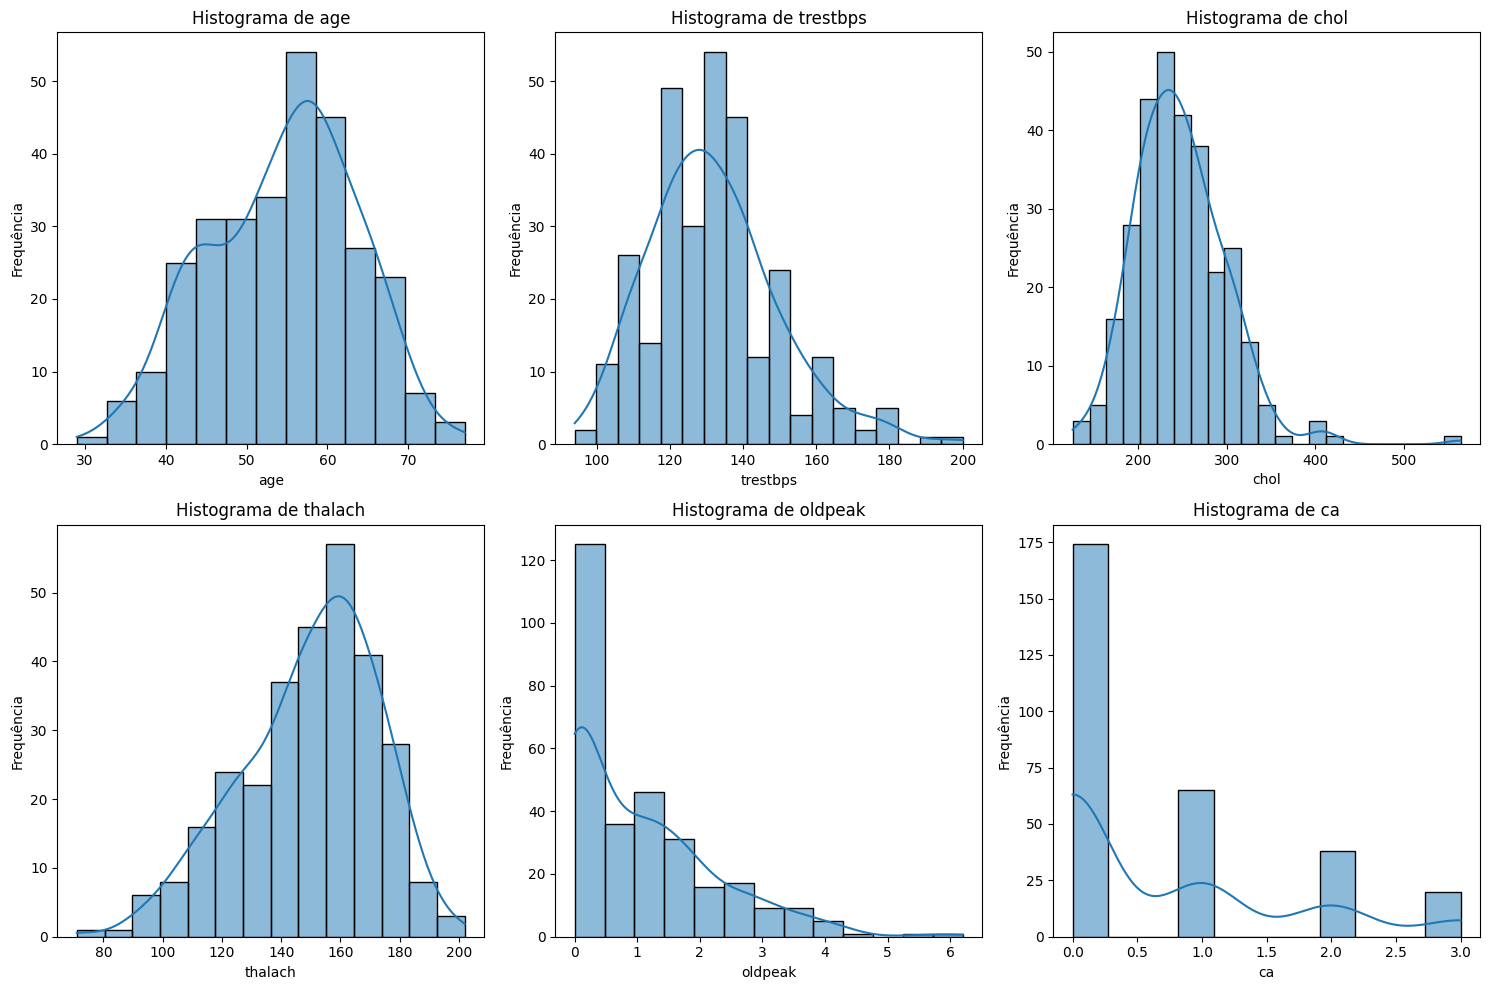

In [10]:
# Gerando gráficos de histogramas dos atributos para verificar suas
# distribuições de probabilidades

import matplotlib.pyplot as plt
import seaborn as sns

def plot_histograms(data):
    numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

    plt.figure(figsize=(15, 10))
    for i, feature in enumerate(numerical_features):
        plt.subplot(2, 3, i + 1) # 2 linhas, 3 colunas
        sns.histplot(data[feature], kde=True)
        # kde=True gera uma linha suave da distribuição de dados.
        # É útil para visualizar tendências
        plt.title(f'Histograma de {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequência')
    plt.tight_layout() # Ajusta o layout para evitar sobreposição
    plt.show()

plot_histograms(X_pos)

In [11]:
# Os histogramas mostram uma distribuição aproximadamente normal para
# os atributos age, trestbps, chole  thalac. Vamos aplicar padronização para
# estes atributos e Min-Max para oldpeak e ca

# Criando o normalizador Min-Max
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler()

# Aplicando a normalização aos atributos selecionados
numerical_features = ['oldpeak', 'ca']
scaled_values = min_max_scaler.fit_transform(X_pos[numerical_features])
# Em dois passos:
#min_max_scaler.fit(X_pos[numerical_features])
#scaled_values = min_max_scaler.transform(X_pos[numerical_features])

# Observação: em uma aplicação real, os dados de teste não devem ser utilizados
# na chamada fit do normalizador
X_normalizado = pd.DataFrame(
    scaled_values,               # valores (scaled values)
    columns=numerical_features,  # nomes das colunas do DataFrame
    index=X_pos.index            # mantendo os mesmos índices das linhas presentes em X_pos
)

In [12]:
print("DataFrame após normalização:")
display(X_normalizado.head())

print("\nEstatísticas descritivas para os atributos numéricos normalizados:")
display(X_normalizado.describe())


DataFrame após normalização:


,oldpeak,ca
0,0.370968,0.000000
1,0.241935,1.000000
2,0.419355,0.666667
3,0.564516,0.000000
4,0.225806,0.000000



Estatísticas descritivas para os atributos numéricos normalizados:


,oldpeak,ca
count,297.000000,297.000000
mean,0.170251,0.225589
std,0.188084,0.312988
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.129032,0.000000
75%,0.258065,0.333333
max,1.000000,1.000000


In [13]:
# Criando o padronizador
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()

# Aplicando a padronização aos atributos selecionados
numerical_features = ['age', 'trestbps', 'chol', 'thalach']
scaled_values = standard_scaler.fit_transform(X_pos[numerical_features])

X_padronizado = pd.DataFrame(
    scaled_values,               # valores (scaled values)
    columns=numerical_features,  # nomes das colunas do DataFrame
    index=X_pos.index            # mantendo os mesmos índices das linhas presentes em X_pos
)

In [14]:
print("DataFrame após padronização:")
display(X_padronizado.head())

print("\nEstatísticas descritivas para os atributos numéricos padronizados:")
display(X_padronizado.describe())


DataFrame após padronização:


,age,trestbps,chol,thalach
0,0.936181,0.750380,-0.276443,0.017494
1,1.378929,1.596266,0.744555,-1.816334
2,1.378929,-0.659431,-0.353500,-0.899420
3,-1.941680,-0.095506,0.051047,1.633010
4,-1.498933,-0.095506,-0.835103,0.978071



Estatísticas descritivas para os atributos numéricos padronizados:


,age,trestbps,chol,thalach
count,2.970000e+02,2.970000e+02,2.970000e+02,2.970000e+02
mean,-1.226105e-16,4.904420e-16,-1.958777e-16,4.784800e-16
std,1.001688e+00,1.001688e+00,1.001688e+00,1.001688e+00
min,-2.827176e+00,-2.125634e+00,-2.337704e+00,-3.431849e+00
25%,-7.241238e-01,-6.594306e-01,-7.002541e-01,-7.247694e-01
50%,1.613719e-01,-9.550637e-02,-8.380217e-02,1.484822e-01
75%,7.148067e-01,4.684179e-01,5.519138e-01,7.160957e-01
max,2.485798e+00,3.851964e+00,6.099981e+00,2.287949e+00


Shape do DataFrame processado: (297, 20)


,sex,fbs,exang,slope,oldpeak,ca,age,trestbps,chol,thalach,cp_1,cp_2,cp_3,cp_4,restecg_0,restecg_1,restecg_2,thal_3.0,thal_6.0,thal_7.0
0,1,1,0,3,0.370968,0.000000,0.936181,0.750380,-0.276443,0.017494,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1,0,1,2,0.241935,1.000000,1.378929,1.596266,0.744555,-1.816334,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2,1,0,1,2,0.419355,0.666667,1.378929,-0.659431,-0.353500,-0.899420,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1,0,0,3,0.564516,0.000000,-1.941680,-0.095506,0.051047,1.633010,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0,0,0,1,0.225806,0.000000,-1.498933,-0.095506,-0.835103,0.978071,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


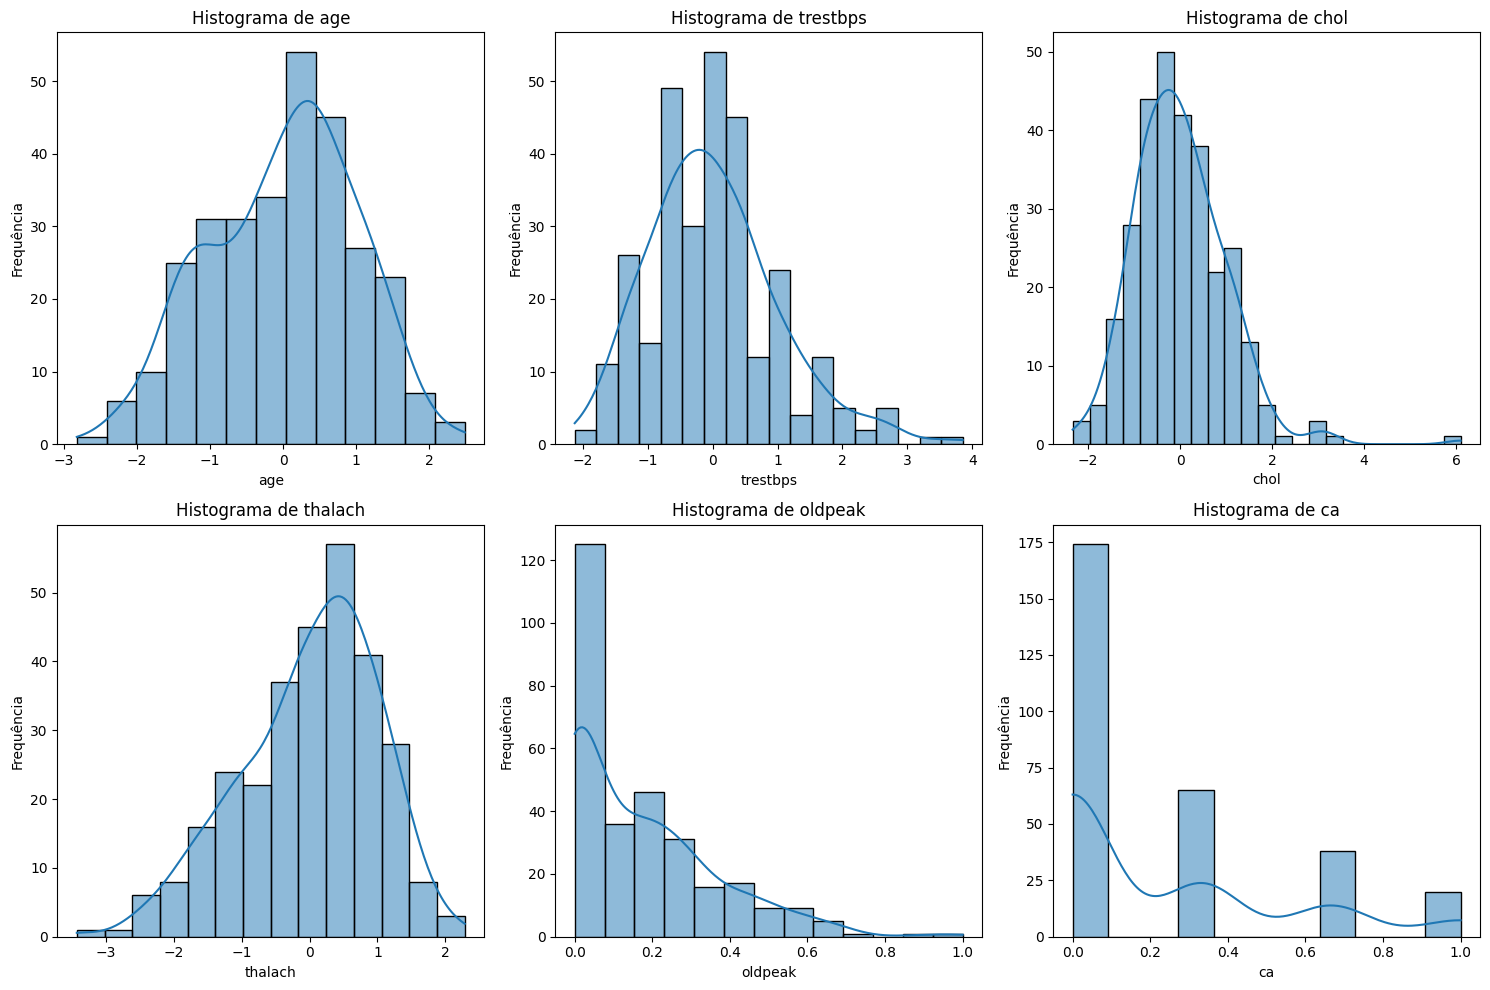

In [15]:
# Criando uma cópia de X_pos sem as colunas transformadas
X_pos_dropped = X_pos.drop(columns=['cp', 'restecg', 'thal', 'age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca'])

# Concatenando X_pos_dropped, X_normalizado, X_padronizado e X_hot_encoded em um novo DataFrame
X_pos_processed = pd.concat([X_pos_dropped, X_normalizado, X_padronizado, X_hot_encoded], axis=1)

print("Shape do DataFrame processado:", X_pos_processed.shape)
display(X_pos_processed.head())

plot_histograms(X_pos_processed)

## Exercício

Avalie o desempenho de um mesmo algoritmo de classificação sobre duas versões do Cleveland Heart Disease Dataset:

- Dataset original sem as instâncias com dados ausentes.
- Dataset sem as instâncias com dados ausentes e com as transformações de atributos preditivos realizadas acima.

Realize a transformação do atributo alvo nas duas versões do dataset.

Nas duas situações, divida o dataset em conjunto de treinamento (70% das instâncias) e conjunto de teste (30% das instâncias).

Não use instâncias de teste para realizar transformações de atributos preditivos.

Ao final, compare o desempenho dos dois modelos sobre os dados do conjunto de teste.

## Referências

* HAN, Jiawei; KAMBER, Micheline; PEI, Jian. **Data Mining: Concepts and Techniques**. 3. ed. Waltham: Morgan Kaufmann, 2011.
* TAN, Pang-Ning; STEINBACH, Michael; KUMAR, Vipin. **Introduction to Data Mining**. 2. ed. NY: Pearson, 2018.
* GÉRON, Aurélien. **Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow**. 3. ed. Sebastopol: O'Reilly Media, 2022.
* FACELI, Katti et al. **Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina**. 3. ed. Rio de Janeiro: LTC, 2025.
* Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). **Heart Disease** [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X.
* Google. **Machine Learning Crash Course**: Normalização. Disponível em <https://developers.google.com/machine-learning/crash-course/numerical-data/normalization?hl=pt-br>. Acesso em 29/09/2026.